In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [83]:
X, y_true = make_blobs(n_samples=1000000, centers=5, cluster_std=5, random_state=42)
# X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=4, random_state=42)

In [84]:
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

In [85]:
df

,Feature_1,Feature_2
0,-10.178931,-8.027721
1,-8.898237,11.159955
2,5.175761,0.179472
3,-5.624181,-9.225514
4,-10.112373,0.703335
...,...,...
999995,0.475701,2.479604
999996,-1.393916,6.487885
999997,-3.041650,14.665662
999998,9.381055,9.450398


In [86]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [87]:
inertia = []  # WCSS
K_range = range(1, 11)

In [88]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


In [89]:
inertia

[1999999.9999999981,
 1298642.5414350303,
 777310.0409217344,
 619992.6025493594,
 517352.379661473,
 451980.336605254,
 390898.2913335067,
 347341.4921372691,
 314301.63867704314,
 284710.0253509392]

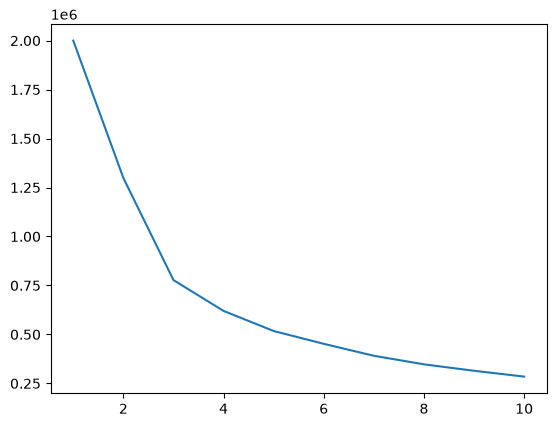

In [90]:
plt.plot(K_range,inertia)

In [91]:
kmeans_final = KMeans(n_clusters=3, random_state=42)

In [92]:
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [93]:
df['cluster'] = cluster_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

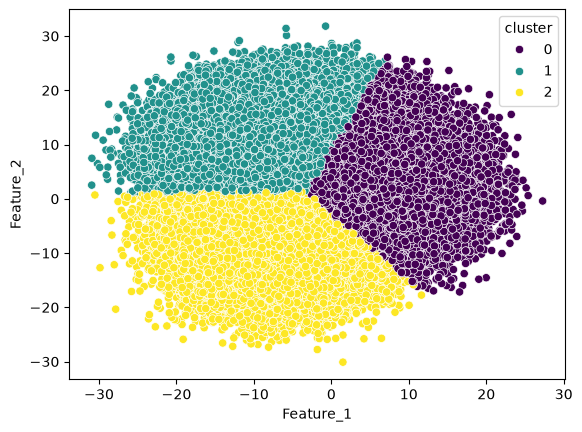

In [94]:
sns.scatterplot(x=df['Feature_1'],
                y=df['Feature_2'],
                hue=df['cluster'],
                palette='viridis')